In [18]:
"""
查看pFind.qry.res文件中q_value<=0.01(按细打分排序)的target PSM和decoy PSM在不同特征上的分布
"""
import os
from utils import *

In [34]:
def get_spec2top1res(res_paths,topk=None):
    if topk is None:
        topk = 1e6
    spec2res = dict()
    for res_path in res_paths:
        print(res_path)
        fr = open(res_path,"r")
        while True:
            line = fr.readline()
            if not line:
                break
            if line.startswith("S"):
                exp_mz = float(line.strip().split("\t")[1])
                spectrum_name = fr.readline().strip()
                best_score = -100
            else:
                items = line.strip().split("\t")
                fine_score = float(items[3])
                if fine_score <= best_score:
                    continue
                best_score = fine_score
                mod_num = int(items[6])
                mods = ""
                for i in range(mod_num):
                    mods += f"{items[7+2*i]},{items[8+2*i]};"
                seq = items[1]
                seq_len = len(seq)
                modified_seq = seq+"\t"+mods
                is_decoy = (items[8+mod_num*2]!='0')
                # intensity_sum/total_intensity,new,seq_ratio,n_ratio,c_ratio,raw_score,matched_peak_num,n_ratio_old,conti_num,not_conti_num,intensity_sum/(pepLen-1),error_mean,error_std
                features = list(reversed([float(items[-i-1]) for i in range(13)]))
                cal_mz = float(items[2])
                mass_shift = (cal_mz/exp_mz-1.0)*1e6
                spec2res[spectrum_name] = [modified_seq,is_decoy,fine_score,*features,mass_shift]
        fr.close()
    return spec2res

In [36]:
"""
step1: meta info
"""
res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/"
# res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/1rerank/"
# res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/1rerank/"
res_paths = [os.path.join(res_dir,filename) for filename in os.listdir(res_dir) if filename.endswith(".qry.res")]

In [38]:
"""
获取正负例
"""
print("collect positive & negative data...")
spec2res = get_spec2top1res(res_paths)
spec_res = [(spectrum_name,res) for spectrum_name,res in spec2res.items()]
spec_res = sorted(spec_res, key=lambda item:item[1][2], reverse=True)
q_values = list()
t,d = 1e-10,0.0
modified_seqs = set()
for spectrum_name,res in spec_res:
    modified_seq,is_decoy,*args = res
    if modified_seq in modified_seqs:
        q_values.append(d/t)
        continue
    if is_decoy:
        d += 1.0
    else:
        t += 1.0
    q_values.append(d/t)
    modified_seqs.add(modified_seq)
min_q_value = 1e6
for i in range(len(q_values)-1,-1,-1):
    q_values[i] = min_q_value = min(q_values[i],min_q_value)
print("Complete!")

pp2features = dict()
np2features = dict()
for i,(spectrum_name,res) in enumerate(spec_res):
    q_value = q_values[i]
    modified_seq,is_decoy,*features = res
    if q_value<=0.01 and not is_decoy and modified_seq not in pp2features:
        pp2features[modified_seq] = features
    elif is_decoy and modified_seq not in np2features:
        np2features[modified_seq] = features

collect positive & negative data...
D:/pFindWorkspace/Astral/new/top50-complete/result/top50-complete.F1.L1.qry.res
D:/pFindWorkspace/Astral/new/top50-complete/result/top50-complete.F2.L1.qry.res
D:/pFindWorkspace/Astral/new/top50-complete/result/top50-complete.F3.L1.qry.res
Complete!


In [319]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(ax, data, plot_type='frequency', bins=10, label='positive', save_path=None):
    """
    绘制浮点数列表的分布图
    
    参数:
    data (list): 包含浮点数的列表
    plot_type (str): 图表类型，可选'histogram'（直方图）或'kde'（核密度估计图）
    bins (int): 直方图的分箱数量
    title (str): 图表标题，默认为None（自动生成标题）
    save_path (str): 图表保存路径，默认为None（不保存）
    
    返回:
    fig, ax: matplotlib的图表和轴对象
    """
    data_array = np.array(data)
    
    # 根据指定类型绘制分布图
    if plot_type == 'frequency':
        ax.hist(data_array, bins=bins, alpha=0.7, edgecolor='black', label=label)
        ax.set_ylabel('Frequency')
    elif plot_type == 'density':
        ax.hist(data_array, bins=bins, alpha=0.7, edgecolor='white', color='#ff7f0e', label=label, density=True)
        ax.set_ylabel('Density')
    elif plot_type == 'kde':
        sns.kdeplot(data_array, ax=ax, label=label, fill=True)
        ax.set_ylabel('Density')
    
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # 保存图表（如果指定了路径）
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)

1.0

In [339]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.special import rel_entr
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# 设置可视化风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

def get_uniform_bins(data1, data2, k=10):
    """生成两组数据共用的等宽 bins，确保柱宽一致"""
    # 计算全局最小和最大值（包含两组数据）
    global_min = min(np.min(data1), np.min(data2))
    global_max = max(np.max(data1), np.max(data2))
    
    # 处理极端情况：如果所有值相同
    if global_min == global_max:
        return np.array([global_min - 0.5, global_min + 0.5])
    
    # 生成等宽 bins（k 个区间，k+1 个边界）
    bins = np.linspace(global_min, global_max, k + 1)
    return bins

def calculate_metrics(data1, data2, bins):
    """计算卡方检验、互信息、对称KL散度"""
    # 将数据映射到 bins 索引（0-based）
    data1_binned = np.digitize(data1, bins, right=False) - 1
    data2_binned = np.digitize(data2, bins, right=False) - 1
    # 确保索引在有效范围内
    data1_binned = np.clip(data1_binned, 0, len(bins)-2)
    data2_binned = np.clip(data2_binned, 0, len(bins)-2)
    # 统计每个分箱的样本数
    count1 = np.bincount(data1_binned, minlength=len(bins)-1)
    count2 = np.bincount(data2_binned, minlength=len(bins)-1)
    
    # 1. 互信息（需构造标签：0=data1，1=data2）
    X = np.concatenate([data1_binned, data2_binned]).reshape(-1, 1)
    y = np.concatenate([np.zeros(len(data1)), np.ones(len(data2))])
    mi = mutual_info_classif(X, y, random_state=42)[0]
    
    # 2. 对称KL散度（使用原始分箱但处理零值）
    p = count1 / len(data1)  # data1的概率分布
    q = count2 / len(data2)  # data2的概率分布
    p = p + 1e-10  # 避免零值
    q = q + 1e-10
    kl_pq = np.sum(rel_entr(p, q))
    kl_qp = np.sum(rel_entr(q, p))
    symmetric_kl = 0.5 * (kl_pq + kl_qp)

    # 3. JS散度
    m = (p+q)/2
    kl_pm = np.sum(rel_entr(p, m))
    kl_qm = np.sum(rel_entr(q, m))
    js = 0.5 * (kl_pm + kl_qm) / np.log(2)  # 注意要以2为底!

    # 4. 对称交叉熵
    ce = 0.5 * (np.sum(-p*np.log(q)) + np.sum(-q*np.log(p)))
    
    return {
        # 'chi2': round(chi2, 4) if not np.isnan(chi2) else 'N/A',
        # 'p_value': round(p_value, 4) if not np.isnan(p_value) else 'N/A',
        'mutual_info': round(mi, 4),
        'symmetric_kl': round(symmetric_kl, 4),
        'js': round(js, 4),
        'ce': round(ce, 4),
    }

def plot_distribution(ax, data1, data2, plot_type='frequency', bins=10, label='positive', save_path=None):
    """
    绘制浮点数列表的分布图
    
    参数:
    data (list): 包含浮点数的列表
    plot_type (str): 图表类型，可选'histogram'（直方图）或'kde'（核密度估计图）
    bins (int): 直方图的分箱数量
    title (str): 图表标题，默认为None（自动生成标题）
    save_path (str): 图表保存路径，默认为None（不保存）
    
    返回:
    fig, ax: matplotlib的图表和轴对象
    """
    data1_array = np.array(data1)
    data2_array = np.array(data2)
    bins = get_uniform_bins(data1, data2, bins)
    
    # 根据指定类型绘制分布图
    if plot_type == 'frequency':
        ax.hist(data1_array, bins=bins, alpha=0.7, edgecolor='black', label=label)
        ax.hist(data2_array, bins=bins, alpha=0.7, edgecolor='black', label=label)
        ax.set_ylabel('Frequency')
    elif plot_type == 'density':
        ax.hist(data1_array, bins=bins, alpha=0.7, edgecolor='white', color='#1f77b4', label=label, density=True)
        ax.hist(data2_array, bins=bins, alpha=0.7, edgecolor='white', color='#ff7f0e', label=label, density=True)
        ax.set_ylabel('Density')
    elif plot_type == 'kde':
        sns.kdeplot(data1_array, ax=ax, label=label, fill=True)
        sns.kdeplot(data2_array, ax=ax, label=label, fill=True)
        ax.set_ylabel('Density')
    
    ax.grid(True, linestyle='--', alpha=0.7)

    # 计算指标
    metrics = calculate_metrics(data1, data2, bins)

    print(metrics)
    # ax.text(0.95, 0.95, f"JS={metrics['js']}", fontsize=10)
    ax.text(
            x=0.95,          # 子图宽度的95%位置（右侧）
            y=0.95,          # 子图高度的95%位置（顶部）
            s=f"JS={metrics['js']}",
            fontsize=10,
            transform=ax.transAxes,  # 关键：使用子图的相对坐标系
            horizontalalignment='right',  # 文本右边缘对齐x坐标
            verticalalignment='top',      # 文本上边缘对齐y坐标
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5')  # 白色背景框
        )

    
    # 保存图表（如果指定了路径）
    if save_path:
        ax.tight_layout()
        ax.savefig(save_path)

20995
fine_score/(seq_len-1)
{'mutual_info': 0.1621, 'symmetric_kl': 3.4523, 'js': 0.6259, 'ce': 5.6259}
intensity_sum/(pepLen-1)
{'mutual_info': 0.1487, 'symmetric_kl': 2.6425, 'js': 0.5721, 'ce': 4.6082}
max_not_conti_ratio
{'mutual_info': 0.0891, 'symmetric_kl': 1.5021, 'js': 0.3775, 'ce': 4.1322}
max_conti_ratio
{'mutual_info': 0.1131, 'symmetric_kl': 2.154, 'js': 0.4884, 'ce': 3.9012}
error_std
{'mutual_info': 0.016, 'symmetric_kl': 0.2552, 'js': 0.0667, 'ce': 2.4971}
error_mean
{'mutual_info': 0.0275, 'symmetric_kl': 0.4512, 'js': 0.1039, 'ce': 2.0052}
raw_score/(seq_len-1)
{'mutual_info': 0.1257, 'symmetric_kl': 2.4788, 'js': 0.5165, 'ce': 4.8984}
n_ratio_old
{'mutual_info': 0.0396, 'symmetric_kl': 0.6826, 'js': 0.1829, 'ce': 3.0478}
seq_ratio
{'mutual_info': 0.1059, 'symmetric_kl': 2.2615, 'js': 0.469, 'ce': 4.6309}
new
{'mutual_info': 0.1996, 'symmetric_kl': 3.8364, 'js': 0.7008, 'ce': 4.4404}
intensity_sum/total_intensity
{'mutual_info': 0.1536, 'symmetric_kl': 2.7434, 'js': 

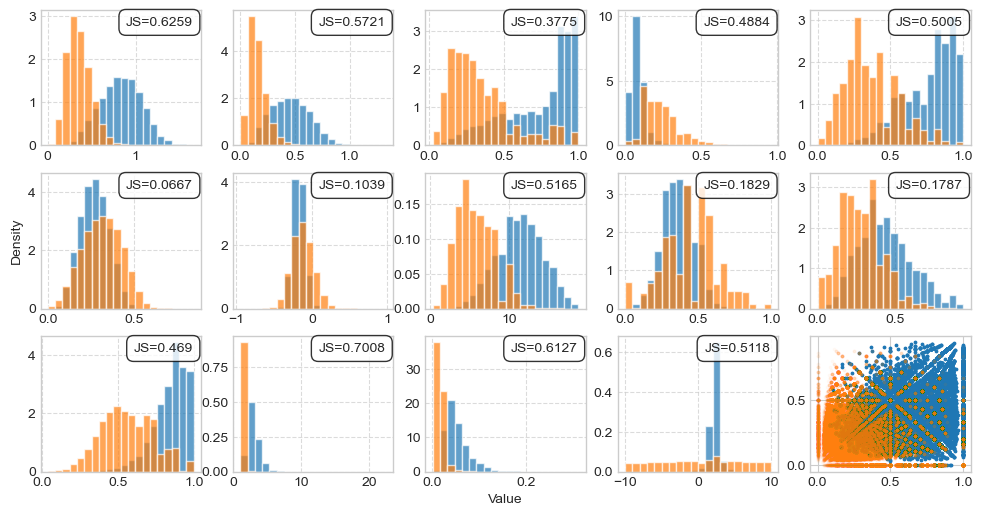

In [341]:
feature_num = 15
pos_featuress = [list() for i in range(feature_num)]
neg_featuress = [list() for i in range(feature_num)]
for modified_seq,features in pp2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==6:
            pos_featuress[i].append(features[i]/(seq_len-1))
        else:
            pos_featuress[i].append(features[i])
for modified_seq,features in np2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==6:
            neg_featuress[i].append(features[i]/(seq_len-1))
        else:
            neg_featuress[i].append(features[i])
pos_featuress = np.array(pos_featuress)
neg_featuress = np.array(neg_featuress)
print(len(pos_featuress[0]))

row,col = 3,5
fig,axes = plt.subplots(row,col,figsize=(12,6))
feature_names = []
# (1)intensity_sum/total_intensity,new,seq_ratio,n_ratio,c_ratio,
# (6)raw_score,matched_peak_num,n_ratio_old,max_conti_ratio,max_not_conti_ratio,
# (11)intensity_sum/(pepLen-1),error_mean,error_std
# fine_score/(seq_len-1)
print("fine_score/(seq_len-1)")
plot_distribution(axes[0,0], pos_featuress[0], neg_featuress[0], plot_type='density', bins=20, label='positive', save_path=None)
axes[0,0].set_ylabel("")
# intensity_sum/(pepLen-1)
print("intensity_sum/(pepLen-1)")
plot_distribution(axes[0,1], pos_featuress[11], neg_featuress[11], plot_type='density', bins=20, label='positive', save_path=None)
axes[0,1].set_ylabel("")
# max_not_conti_ratio
print("max_not_conti_ratio")
plot_distribution(axes[0,2], pos_featuress[9], neg_featuress[9], plot_type='density', bins=20, label='positive', save_path=None)
axes[0,2].set_ylabel("")
# max_conti_ratio
print("max_conti_ratio")
plot_distribution(axes[0,3], pos_featuress[10], neg_featuress[10], plot_type='density', bins=20, label='positive', save_path=None)
axes[0,3].set_ylabel("")
# error_std
print("error_std")
plot_distribution(axes[1,0], pos_featuress[13], neg_featuress[13], plot_type='density', bins=20, label='positive', save_path=None)
axes[1,0].set_ylabel("Density")
# error_mean
print("error_mean")
plot_distribution(axes[1,1], pos_featuress[12], neg_featuress[12], plot_type='density', bins=20, label='positive', save_path=None)
axes[1,1].set_ylabel("")
# raw_score/(seq_len-1)
print("raw_score/(seq_len-1)")
plot_distribution(axes[1,2], pos_featuress[6], neg_featuress[6], plot_type='density', bins=20, label='positive', save_path=None)
axes[1,2].set_ylabel("")
# n_ratio_old
print("n_ratio_old")
plot_distribution(axes[1,3], pos_featuress[8], neg_featuress[8], plot_type='density', bins=20, label='positive', save_path=None)
axes[1,3].set_ylabel("")
# seq_ratio
print("seq_ratio")
plot_distribution(axes[2,0], pos_featuress[3], neg_featuress[3], plot_type='density', bins=20, label='positive', save_path=None)
axes[2,0].set_ylabel("")
# new
print("new")
plot_distribution(axes[2,1], pos_featuress[2], neg_featuress[2], plot_type='density', bins=20, label='positive', save_path=None)
axes[2,1].set_ylabel("")
# intensity_sum/total_intensity
print("intensity_sum/total_intensity")
plot_distribution(axes[2,2], pos_featuress[1], neg_featuress[1], plot_type='density', bins=20, label='positive', save_path=None)
axes[2,2].set_ylabel("")
axes[2,2].set_xlabel("Value")
# mass_shift
print("mass_shift")
plot_distribution(axes[2,3], pos_featuress[-1], neg_featuress[-1], plot_type='density', bins=20, label='positive', save_path=None)
axes[2,3].set_ylabel("")
# c_ratio
print("c_ratio")
plot_distribution(axes[0,4], pos_featuress[5], neg_featuress[5], plot_type='density', bins=20, label='positive', save_path=None)
axes[0,4].set_ylabel("")
# n_ratio
print("n_ratio")
plot_distribution(axes[1,4], pos_featuress[4], neg_featuress[4], plot_type='density', bins=20, label='positive', save_path=None)
axes[1,4].set_ylabel("")
# n_ratio,c_ratio: scatter
axes[2,4].scatter(pos_featuress[5],pos_featuress[4],color='#1f77b4',label='positive',s=3)
axes[2,4].scatter(neg_featuress[5],neg_featuress[4],color='#ff7f0e',label='negative',s=3,alpha=0.03)
# axes[2,4].legend()

In [349]:
# spectrum_path = "D:/data/ms/Astral/PXD046357-Single_Cell/top50/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512_HCDAST.mgf"
spectrum_path = "D:/data/ms/Astral/PXD046357-Single_Cell/top50/peaks.mgf"
out_path = "D:/data/ms/Astral/PXD046357-Single_Cell/top50/peaks_2000.mgf"
cnt = 0
fr = open(spectrum_path, "r")
fw = open(out_path, "w")
for line in fr:
    if line.startswith("B"):
        lines = []
        lines.append(line)
    elif line.startswith("E"):
        lines.append(line)
        if len(lines)>1500:
            for l in lines:
                fw.write(l)
            cnt += 1
        lines = []
    else:
        lines.append(line)
fr.close()
fw.close()
print(cnt)

12470


20995


TypeError: plot_distribution() missing 1 required positional argument: 'data2'

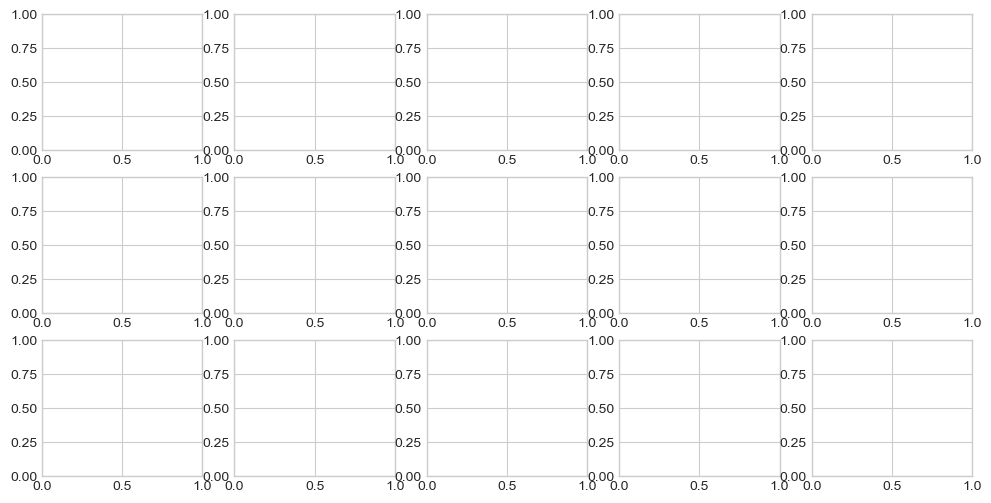

In [243]:
feature_num = 15
pos_featuress = [list() for i in range(feature_num)]
neg_featuress = [list() for i in range(feature_num)]
for modified_seq,features in pp2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==6:
            pos_featuress[i].append(features[i]/(seq_len-1))
        else:
            pos_featuress[i].append(features[i])
for modified_seq,features in np2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==6:
            neg_featuress[i].append(features[i]/(seq_len-1))
        else:
            neg_featuress[i].append(features[i])
pos_featuress = np.array(pos_featuress)
neg_featuress = np.array(neg_featuress)
print(len(pos_featuress[0]))

row,col = 3,5
fig,axes = plt.subplots(row,col,figsize=(12,6))
feature_names = []
# (1)intensity_sum/total_intensity,new,seq_ratio,n_ratio,c_ratio,
# (6)raw_score,matched_peak_num,n_ratio_old,max_conti_ratio,max_not_conti_ratio,
# (11)intensity_sum/(pepLen-1),error_mean,error_std

# fine_score/(seq_len-1)
plot_distribution(axes[0,0], pos_featuress[0], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,0], neg_featuress[0], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,0].set_ylabel("")
# intensity_sum/(pepLen-1)
plot_distribution(axes[0,1], pos_featuress[11], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,1], neg_featuress[11], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,1].set_ylabel("")
# max_not_conti_ratio
plot_distribution(axes[0,2], pos_featuress[9], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,2], neg_featuress[9], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,2].set_ylabel("")
# max_conti_ratio
plot_distribution(axes[0,3], pos_featuress[10], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,3], neg_featuress[10], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,3].set_ylabel("")
# error_std
plot_distribution(axes[1,0], pos_featuress[13], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,0], neg_featuress[13], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,0].set_ylabel("Density")
# error_mean
plot_distribution(axes[1,1], pos_featuress[12], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,1], neg_featuress[12], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,1].set_ylabel("")
# raw_score/(seq_len-1)
plot_distribution(axes[1,2], pos_featuress[6], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,2], neg_featuress[6], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,2].set_ylabel("")
# n_ratio_old
plot_distribution(axes[1,3], pos_featuress[8], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,3], neg_featuress[8], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,3].set_ylabel("")
# seq_ratio
plot_distribution(axes[2,0], pos_featuress[3], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,0], neg_featuress[3], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,0].set_ylabel("")
# new
plot_distribution(axes[2,1], pos_featuress[2], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,1], neg_featuress[2], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,1].set_ylabel("")
# intensity_sum/total_intensity
plot_distribution(axes[2,2], pos_featuress[1], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,2], neg_featuress[1], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,2].set_ylabel("")
axes[2,2].set_xlabel("Value")
# mass_shift
plot_distribution(axes[2,3], pos_featuress[-1], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,3], neg_featuress[-1], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,3].set_ylabel("")
# c_ratio
plot_distribution(axes[0,4], pos_featuress[5], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,4], neg_featuress[5], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,4].set_ylabel("")
# n_ratio
plot_distribution(axes[1,4], pos_featuress[4], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,4], neg_featuress[4], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,4].set_ylabel("")
# n_ratio,c_ratio: scatter
axes[2,4].scatter(pos_featuress[5],pos_featuress[5],label='positive',s=3)
axes[2,4].scatter(neg_featuress[5],neg_featuress[4],label='negative',s=3,alpha=0.03)
# axes[2,4].legend()

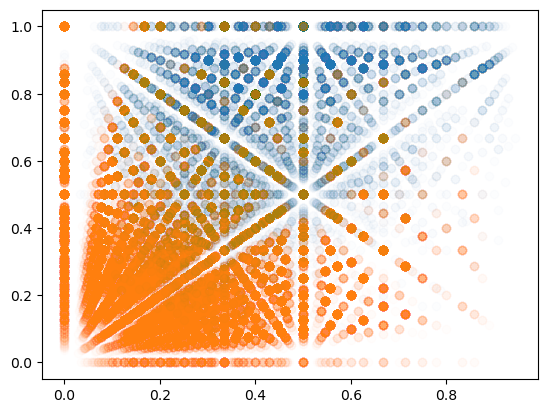

In [46]:
# plt.scatter(pos_featuress[13],[1 for i in range(len(pos_featuress[3]))],label='positive')
# plt.scatter(neg_featuress[13],[1 for i in range(len(neg_featuress[3]))],label='negative',alpha=0.1)


plt.scatter(pos_featuress[4],pos_featuress[5],label='positive',alpha=0.01)
plt.scatter(neg_featuress[4],neg_featuress[5],label='negative',alpha=0.01)
plt.show()

In [229]:
neg_featuress[1][0],neg_featuress[1][0]
pos_featuress[2][0],pos_featuress[2][0]
neg_featuress[9][0],neg_featuress[9][0]
pos_featuress[11][0],pos_featuress[11][0]

(0.0, 0.0)

In [233]:
pos_featuress[1][0],pos_featuress[2][0],pos_featuress[9][0],pos_featuress[11][0]
# neg_featuress[1][0],neg_featuress[2][0],neg_featuress[9][0],neg_featuress[11][0]

(0.642857, 0.47619, 0.464286, 0.952381)